<a href="https://colab.research.google.com/github/Nikolexion/GenerativeDeepLearning/blob/main/GDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploración y limpieza de datos — Proyecto AMP (Fase 1)
==========================================================
Corre esto en Google Colab (Entorno de ejecución -> Cambiar tipo de
entorno -> GPU, aunque para esta fase no necesitas GPU todavía).

Pasos:
  1. Descargar datos crudos de HydrAMP (vía Google Drive)
  2. Cargar y explorar (tamaño, columnas, duplicados, distribución de labels)
  3. Limpiar (duplicados, longitud, secuencias con caracteres inválidos)
  4. Etiquetar toxicidad (HC50) con HemoPI2 sobre las secuencias de HydrAMP
  5. Guardar dataset unificado: sequence, cAMP, cMIC, cHC50
  

In [1]:
# ==========================================================
# SETUP — correr esto cada vez que se reinicia la sesión de Colab
# ==========================================================
import gdown
import pandas as pd
import subprocess
import os
import csv
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/GeneracionAMP"
DATA_DIR = f"{BASE_DIR}/data_raw/data"
PROC_DIR = f"{BASE_DIR}/data_processed"
LOG_PATH = f"{PROC_DIR}/log_entrenamiento_baseline.csv"
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(f"{PROC_DIR}/hemopi2_work", exist_ok=True)


# El venv ahora vive en Drive (no en /content/), así persiste entre sesiones.
# python3.11 como paquete del sistema sí hay que reasegurarlo cada vez
# (rápido gracias al caché de apt, unos segundos).
VENV_PATH = f"{BASE_DIR}/env_hemopi2"

r1 = subprocess.run(["sudo", "apt-get", "update"], capture_output=True, text=True)
r2 = subprocess.run(["sudo", "apt-get", "install", "-y", "python3.11", "python3.11-venv"], capture_output=True, text=True)
if r2.returncode != 0:
    print(r2.stderr[-1500:])
    raise RuntimeError("apt-get install falló, revisa el stderr impreso arriba")

if not os.path.exists(VENV_PATH):
    print("Creando venv en Drive (solo la primera vez)...")
    subprocess.run(["python3.11", "-m", "venv", VENV_PATH], check=True)
else:
    print("venv ya existe en Drive, reutilizando.")

if not os.path.exists(f"{VENV_PATH}/bin/hemopi2_regression"):
    print("Instalando hemopi2 dentro del venv...")
    subprocess.run([f"{VENV_PATH}/bin/pip", "install", "hemopi2"], check=True)
else:
    print("hemopi2 ya está instalado en el venv persistente.")

if not os.path.exists(LOG_PATH):
    with open(LOG_PATH, "w", newline="") as f:
        csv.writer(f).writerow(["epoch", "loss_total", "loss_noise", "loss_round"])

env_venv = os.environ.copy()
env_venv["PATH"] = f"{VENV_PATH}/bin:" + env_venv["PATH"]

Mounted at /content/drive
venv ya existe en Drive, reutilizando.
hemopi2 ya está instalado en el venv persistente.


In [2]:
# ==========================================================
# 1. Descargar datos crudos de HydrAMP
# ==========================================================
# El repo oficial (github.com/szczurek-lab/hydramp) apunta los datos
# a esta carpeta de Google Drive vía DVC:
HYDRAMP_DRIVE_LINK = "https://drive.google.com/drive/folders/1krim1ugqNDmgmHZCFSOvmynWxCSzyOto"

os.makedirs("data_raw", exist_ok=True)
#gdown.download_folder(HYDRAMP_DRIVE_LINK, output="data_raw", quiet=False)

# NOTA: revisa qué queda dentro de data_raw/ después de correr esto —
# la estructura exacta de subcarpetas puede variar. Ajusta la ruta
# del siguiente paso según lo que encuentres (busca los CSV de train/test/val,
# probablemente bajo algo como data_raw/data/unlabelled_positive.csv,
# data_raw/data/unlabelled_negative.csv, etc.)

DATA_DIR = "/content/drive/MyDrive/GeneracionAMP/data_raw/data"


In [3]:
# ==========================================================
# 2. Cargar y explorar cada fuente por separado
# ==========================================================
def explorar(df_in: pd.DataFrame, nombre: str, col_seq_candidata: str = None):
    print(f"\n=== {nombre} ===")
    print("Shape:", df_in.shape)
    print("Columnas:", df_in.columns.tolist())
    print(df_in.head(3))
    print("Nulos por columna:\n", df_in.isnull().sum())
    if col_seq_candidata and col_seq_candidata in df_in.columns:
        largos = df_in[col_seq_candidata].str.len()
        print("Longitud secuencia -> min/mean/max:", largos.min(), largos.mean(), largos.max())

df_mic = pd.read_csv(f"{DATA_DIR}/mic_data.csv")
df_pos = pd.read_csv(f"{DATA_DIR}/veltri_positive.csv")
df_neg = pd.read_csv(f"{DATA_DIR}/veltri_negative.csv")

# Los archivos NO comparten el mismo nombre de columna para la secuencia:
#   mic_data.csv          -> 'sequence' (minúscula), MIC en columna 'value'
#   veltri_positive/negative.csv -> 'Sequence' (mayúscula), más 'Name' (id)
# Estandarizamos todo a 'sequence' antes de seguir.
df_pos = df_pos.rename(columns={"Sequence": "sequence"})
df_neg = df_neg.rename(columns={"Sequence": "sequence"})
df_mic = df_mic.drop(columns=["Unnamed: 0"])  # índice residual del CSV original

explorar(df_mic, "mic_data.csv")
explorar(df_pos, "veltri_positive.csv")
explorar(df_neg, "veltri_negative.csv")

# Confirmado con datos reales:
COL_SEQ = "sequence"
COL_MIC = "value"

# NOTA sobre 'value': los valores (ej. 1.0, 1.9, 2.1) sugieren que ya está
# en escala logarítmica (probablemente log10 del MIC en µM), no MIC crudo.
# Verifica esto antes de aplicar tú mismo otra transformación log — si ya
# está en log, NO la vuelvas a aplicar en el pipeline de entrenamiento.



=== mic_data.csv ===
Shape: (4546, 2)
Columnas: ['sequence', 'value']
                            sequence    value
0  AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS  2.09995
1       AAAAAAAIKMLMDLVNERIMALNKKAKK  1.00000
2                   AAAKAALNAVLVGANA  1.90309
Nulos por columna:
 sequence    0
value       0
dtype: int64

=== veltri_positive.csv ===
Shape: (2021, 2)
Columnas: ['Name', 'sequence']
      Name                                     sequence
0  AP02484                        GMASKAGSVLGKITKIALGAL
1  AP02630  NIGLFTSTCFSSQCFSSKCFTDTCFSSNCFTGRHQCGYTHGSC
2  AP01427               GAIKDALKGAAKTVAVELLKKAQCKLEKTC
Nulos por columna:
 Name        0
sequence    0
dtype: int64

=== veltri_negative.csv ===
Shape: (1897, 2)
Columnas: ['Name', 'sequence']
              Name                     sequence
0  UniRef50_A0QYG2             EGAVSGVEGLPSGSAL
1  UniRef50_Q9FKB0  ELIDRCIGSKIWVIMKGDKELVGILKG
2  UniRef50_P33768    QNIQDRIKMYIKKEEEEPTNFKNPF
Nulos por columna:
 Name        0
sequence    0
dtype

In [4]:
# ==========================================================
# 3. Limpieza
# ==========================================================
AMINOACIDOS_VALIDOS = set("ACDEFGHIKLMNPQRSTVWY")
MIN_LEN, MAX_LEN = 5, 50

def secuencia_valida(seq: str) -> bool:
    """True si la secuencia solo contiene los 20 aminoácidos estándar."""
    if not isinstance(seq, str) or len(seq) == 0:
        return False
    return set(seq.upper()).issubset(AMINOACIDOS_VALIDOS)

def limpiar(df_in: pd.DataFrame, col_seq: str, nombre: str) -> pd.DataFrame:
    d = df_in.copy()
    n0 = len(d)
    d = d[d[col_seq].apply(secuencia_valida)]
    n1 = len(d)
    d = d.drop_duplicates(subset=[col_seq])
    n2 = len(d)
    d = d[d[col_seq].str.len().between(MIN_LEN, MAX_LEN)]
    n3 = len(d)
    print(f"{nombre}: {n0} -> {n1} (caracteres inválidos) -> {n2} (duplicados) -> {n3} (longitud)")
    return d

df_pos_clean = limpiar(df_pos, COL_SEQ, "veltri_positive")
df_neg_clean = limpiar(df_neg, COL_SEQ, "veltri_negative")
df_mic_clean = limpiar(df_mic, COL_SEQ, "mic_data")

# Etiqueta cAMP: 1 para positivas, 0 para negativas
df_pos_clean["cAMP"] = 1
df_neg_clean["cAMP"] = 0
df_amp = pd.concat([df_pos_clean[[COL_SEQ, "cAMP"]], df_neg_clean[[COL_SEQ, "cAMP"]]], ignore_index=True)
df_amp = df_amp.drop_duplicates(subset=[COL_SEQ])  # por si alguna secuencia aparece en ambos (raro, pero revisar)

# Merge con MIC (left join: no todas las secuencias de veltri van a tener MIC medido)
df_clean = df_amp.merge(df_mic_clean[[COL_SEQ, COL_MIC]], on=COL_SEQ, how="left")
print(f"\nSecuencias con cAMP: {len(df_amp)}")
print(f"Secuencias con cAMP + cMIC no nulo: {df_clean[COL_MIC].notna().sum()}")
print(f"\nDataset final limpio (antes de toxicidad): {len(df_clean)} secuencias")


veltri_positive: 2021 -> 2021 (caracteres inválidos) -> 2021 (duplicados) -> 1722 (longitud)
veltri_negative: 1897 -> 1897 (caracteres inválidos) -> 1897 (duplicados) -> 1605 (longitud)
mic_data: 4546 -> 4546 (caracteres inválidos) -> 4546 (duplicados) -> 4399 (longitud)

Secuencias con cAMP: 3327
Secuencias con cAMP + cMIC no nulo: 897

Dataset final limpio (antes de toxicidad): 3327 secuencias


In [6]:
# ==========================================================
# 4. Etiquetar toxicidad (HC50) con HemoPI2
# ==========================================================
def escribir_fasta(df_in, col_seq, path_out):
    with open(path_out, "w") as f:
        for i, seq in enumerate(df_in[col_seq]):
            f.write(f">seq_{i}\n{seq}\n")

FASTA_PATH = f"{PROC_DIR}/hydramp_clean.fasta"
escribir_fasta(df_clean, COL_SEQ, FASTA_PATH)

RUTA_HC50 = f"{PROC_DIR}/hemopi2_work/hc50_predicho.csv"

if os.path.exists(RUTA_HC50):
    print("hc50_predicho.csv ya existe en Drive, cargando directo (sin recalcular)...")
    df_hc50 = pd.read_csv(RUTA_HC50)
else:
    resultado_hemopi2 = subprocess.run(
        ["/content/env_hemopi2/bin/hemopi2_regression", "-i",
         FASTA_PATH, "-o",
         "hc50_predicho.csv", "-j", "1",
         "-wd", f"{PROC_DIR}/hemopi2_work"],
        capture_output=True, text=True, env=env_venv
    )
    print("STDOUT:", resultado_hemopi2.stdout)
    print("STDERR:", resultado_hemopi2.stderr)
    print("Return code:", resultado_hemopi2.returncode)
    if resultado_hemopi2.returncode != 0:
        raise RuntimeError("hemopi2_regression falló, revisa STDERR arriba")
    df_hc50 = pd.read_csv(RUTA_HC50)

print("\nColumnas:", df_hc50.columns.tolist())
print(df_hc50.head())

hc50_predicho.csv ya existe en Drive, cargando directo (sin recalcular)...

Columnas: ['SeqID', 'Sequence', 'HC50(μM)', 'Prediction']
   SeqID                                  Sequence  HC50(μM)     Prediction
0  seq_0                     GMASKAGSVLGKITKIALGAL   173.936  Non-Hemolytic
1  seq_1  NIGLFTSTCFSSQCFSSKCFTDTCFSSNCFTGRHQCGYTH    25.671      Hemolytic
2  seq_2            GAIKDALKGAAKTVAVELLKKAQCKLEKTC   215.073  Non-Hemolytic
3  seq_3                     FFGRLKAVFRGARQGWKEHRY    98.976      Hemolytic
4  seq_4  DFGCARGMIFVCMRRCARMYPGSTGYCQGFRCMCDTMIPI    38.412      Hemolytic


In [7]:
# Verificación: ¿HemoPI2 truncó alguna secuencia?
df_check = df_clean.reset_index(drop=True).copy()
df_check["seq_id_esperado"] = [f"seq_{i}" for i in range(len(df_check))]

comparacion = df_check[["seq_id_esperado", COL_SEQ]].merge(
    df_hc50[["SeqID", "Sequence"]],
    left_on="seq_id_esperado", right_on="SeqID"
)
comparacion["largo_original"] = comparacion[COL_SEQ].str.len()
comparacion["largo_hemopi2"] = comparacion["Sequence"].str.len()
comparacion["truncada"] = comparacion["largo_original"] != comparacion["largo_hemopi2"]

print(f"Secuencias truncadas por HemoPI2: {comparacion['truncada'].sum()} de {len(comparacion)}")
print(comparacion[comparacion["truncada"]].head())

Secuencias truncadas por HemoPI2: 386 de 3327
   seq_id_esperado                                           sequence   SeqID  \
1            seq_1        NIGLFTSTCFSSQCFSSKCFTDTCFSSNCFTGRHQCGYTHGSC   seq_1   
4            seq_4   DFGCARGMIFVCMRRCARMYPGSTGYCQGFRCMCDTMIPIRRPPFIMG   seq_4   
8            seq_8       FKKKKRNIGTFVFFAIALFCTVMFAYLLLTNQYVPIDYNVPRYA   seq_8   
19          seq_19        GVWDWIKKTAGKIWNSEPVKALKSQALNAAKNFVAEKIGATPS  seq_19   
21          seq_21  LSCRFGRIACIGTCQVQNCGTGYCRGDTCVCSRCGTGGIVGVSVGKKRR  seq_21   

                                    Sequence  largo_original  largo_hemopi2  \
1   NIGLFTSTCFSSQCFSSKCFTDTCFSSNCFTGRHQCGYTH              43             40   
4   DFGCARGMIFVCMRRCARMYPGSTGYCQGFRCMCDTMIPI              48             40   
8   FKKKKRNIGTFVFFAIALFCTVMFAYLLLTNQYVPIDYNV              44             40   
19  GVWDWIKKTAGKIWNSEPVKALKSQALNAAKNFVAEKIGA              43             40   
21  LSCRFGRIACIGTCQVQNCGTGYCRGDTCVCSRCGTGGIV              49            

In [8]:
# ==========================================================
# 5. Unificar dataset final: sequence, cAMP, cMIC, cHC50 + máscaras
# ==========================================================
df_clean = df_clean.reset_index(drop=True)
df_hc50 = df_hc50.reset_index(drop=True)

# Alineamos por posición (seq_0, seq_1, ... en el mismo orden en que
# se escribió el FASTA a partir de df_clean)
df_final = pd.DataFrame({
    "sequence": df_clean[COL_SEQ].values,
    "cAMP": df_clean["cAMP"].values,
    "cMIC": df_clean[COL_MIC].values,
    "mic_available": df_clean[COL_MIC].notna().astype(int).values,
    "cHC50": df_hc50["HC50(μM)"].values,
    "hc50_valido": (df_clean[COL_SEQ].str.len() <= 40).astype(int).values,
})

# Reporte final
print("Dataset final:", df_final.shape)
print(f"  Con cMIC válido: {df_final['mic_available'].sum()} ({df_final['mic_available'].mean():.1%})")
print(f"  Con cHC50 válido (no truncado): {df_final['hc50_valido'].sum()} ({df_final['hc50_valido'].mean():.1%})")
print(f"  Con las tres condiciones válidas simultáneamente: "
      f"{((df_final['mic_available']==1) & (df_final['hc50_valido']==1)).sum()}")

df_final.to_csv(f"{PROC_DIR}/dataset_unificado.csv", index=False)
print(f"\nGuardado en {PROC_DIR}/dataset_unificado.csv")
df_final.head()

Dataset final: (3327, 6)
  Con cMIC válido: 897 (27.0%)
  Con cHC50 válido (no truncado): 2941 (88.4%)
  Con las tres condiciones válidas simultáneamente: 822

Guardado en /content/drive/MyDrive/GeneracionAMP/data_processed/dataset_unificado.csv


,sequence,cAMP,cMIC,mic_available,cHC50,hc50_valido
0,GMASKAGSVLGKITKIALGAL,1,1.091000,1,173.936,1
1,NIGLFTSTCFSSQCFSSKCFTDTCFSSNCFTGRHQCGYTHGSC,1,NaN,0,25.671,0
2,GAIKDALKGAAKTVAVELLKKAQCKLEKTC,1,1.266546,1,215.073,1
3,FFGRLKAVFRGARQGWKEHRY,1,NaN,0,98.976,1
4,DFGCARGMIFVCMRRCARMYPGSTGYCQGFRCMCDTMIPIRRPPFIMG,1,0.707975,1,38.412,0


# Distribucion de variables

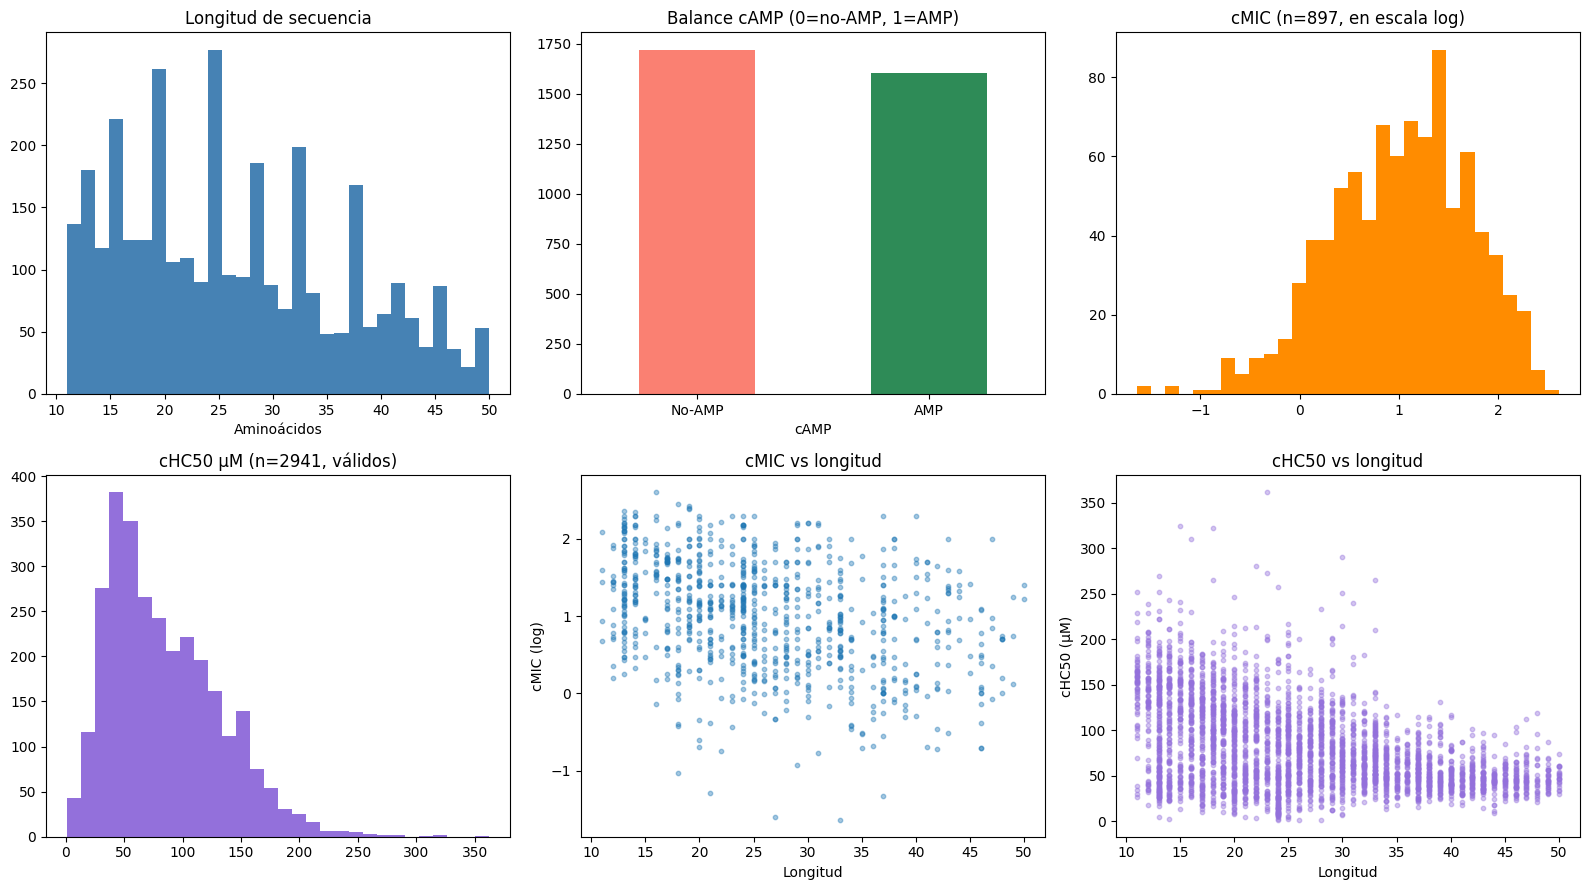

             cMIC        cHC50
count  897.000000  3327.000000
mean     1.014529    80.593267
std      0.703850    47.068917
min     -1.640592     1.312000
25%      0.511948    44.802000
50%      1.080158    68.219000
75%      1.518442   110.188500
max      2.612784   362.361000

Balance cAMP:
 cAMP
1    0.517583
0    0.482417
Name: proportion, dtype: float64


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Longitud de secuencia
axes[0,0].hist(df_final["sequence"].str.len(), bins=30, color="steelblue")
axes[0,0].set_title("Longitud de secuencia")
axes[0,0].set_xlabel("Aminoácidos")

# 2. Balance de clases cAMP
df_final["cAMP"].value_counts().plot(kind="bar", ax=axes[0,1], color=["salmon","seagreen"])
axes[0,1].set_title("Balance cAMP (0=no-AMP, 1=AMP)")
axes[0,1].set_xticklabels(["No-AMP","AMP"], rotation=0)

# 3. Distribución de cMIC (solo donde es válido)
axes[0,2].hist(df_final.loc[df_final["mic_available"]==1, "cMIC"], bins=30, color="darkorange")
axes[0,2].set_title(f"cMIC (n={df_final['mic_available'].sum()}, en escala log)")

# 4. Distribución de cHC50 (solo donde es válido)
axes[1,0].hist(df_final.loc[df_final["hc50_valido"]==1, "cHC50"], bins=30, color="mediumpurple")
axes[1,0].set_title(f"cHC50 μM (n={df_final['hc50_valido'].sum()}, válidos)")

# 5. cMIC vs longitud (por si hay sesgo de longitud en las que tienen MIC medido)
axes[1,1].scatter(df_final["sequence"].str.len(), df_final["cMIC"], alpha=0.4, s=10)
axes[1,1].set_title("cMIC vs longitud")
axes[1,1].set_xlabel("Longitud"); axes[1,1].set_ylabel("cMIC (log)")

# 6. cHC50 vs longitud
axes[1,2].scatter(df_final["sequence"].str.len(), df_final["cHC50"], alpha=0.4, s=10, color="mediumpurple")
axes[1,2].set_title("cHC50 vs longitud")
axes[1,2].set_xlabel("Longitud"); axes[1,2].set_ylabel("cHC50 (μM)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/GeneracionAMP/data_processed/distribuciones_fase1.png", dpi=200, bbox_inches="tight")
plt.show()

# Resumen numérico
print(df_final[["cMIC","cHC50"]].describe())
print("\nBalance cAMP:\n", df_final["cAMP"].value_counts(normalize=True))

## Tokenización

In [10]:
import torch
import torch.nn as nn
import numpy as np
import math

# Vocabulario: 20 aminoácidos + token de padding
AMINOACIDOS = "ACDEFGHIKLMNPQRSTVWY"
VOCAB = {aa: i + 1 for i, aa in enumerate(AMINOACIDOS)}  # 1..20
VOCAB["<PAD>"] = 0
VOCAB_SIZE = len(VOCAB)  # 21

MAX_LEN = 50  # mismo límite que usaste en la limpieza (Fase 1)

def codificar(seq: str, max_len: int = MAX_LEN) -> list[int]:
    ids = [VOCAB[aa] for aa in seq]
    ids = ids[:max_len]
    ids += [VOCAB["<PAD>"]] * (max_len - len(ids))
    return ids

def decodificar(ids: list[int]) -> str:
    inv = {v: k for k, v in VOCAB.items()}
    return "".join(inv[i] for i in ids if i != VOCAB["<PAD>"])

# Dataset de PyTorch
class PeptidosDataset(torch.utils.data.Dataset):
    def __init__(self, df, col_seq: str, max_len: int = MAX_LEN):
        self.seqs = df[col_seq].tolist()
        self.max_len = max_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        ids = torch.tensor(codificar(seq, self.max_len), dtype=torch.long)
        mask = (ids != VOCAB["<PAD>"]).float()  # 1 donde hay aminoácido real, 0 en padding
        return ids, mask

dataset_baseline = PeptidosDataset(df_final, "sequence")
print(f"Dataset: {len(dataset_baseline)} secuencias, largo fijo {MAX_LEN}")

# Chequeo rápido: probar un ejemplo
ids_ej, mask_ej = dataset_baseline[0]
print("Secuencia original:", df_final['sequence'].iloc[0])
print("Reconstruida:", decodificar(ids_ej.tolist()))

Dataset: 3327 secuencias, largo fijo 50
Secuencia original: GMASKAGSVLGKITKIALGAL
Reconstruida: GMASKAGSVLGKITKIALGAL


## Arquitectura: embedding + red de denoising + schedule de difusión

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

EMBED_DIM = 64      # dimensión del embedding continuo por aminoácido
T = 500              # pasos de difusión (más chico que los 1000 de EDM, por tiempo/recursos)
N_LAYERS = 4          # capas del transformer de denoising
N_HEADS = 4

# --- Embedding (entrenado desde cero, junto con el resto) ---
class PeptideEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=VOCAB["<PAD>"])
        self.pos_embed = nn.Embedding(max_len, embed_dim)

    def forward(self, ids):
        # ids: (batch, max_len)
        positions = torch.arange(ids.size(1), device=ids.device).unsqueeze(0)
        return self.embed(ids) + self.pos_embed(positions)

# --- Embedding de timestep (sinusoidal, igual espíritu que EDM/DDPM clásico) ---
def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# --- Red de denoising: Transformer encoder simple ---
class DenoisingNet(nn.Module):
    def __init__(self, embed_dim, n_layers, n_heads, max_len):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.SiLU(), nn.Linear(embed_dim, embed_dim)
        )
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
            batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x_noisy, t, mask):
        # x_noisy: (batch, max_len, embed_dim), t: (batch,), mask: (batch, max_len)
        t_emb = self.time_mlp(timestep_embedding(t, x_noisy.size(-1)))  # (batch, embed_dim)
        x = x_noisy + t_emb.unsqueeze(1)  # se suma a cada posición
        pad_mask = (mask == 0)  # True donde es padding, para que el transformer lo ignore
        h = self.transformer(x, src_key_padding_mask=pad_mask)
        return self.out_proj(h)

# --- Schedule de difusión (coseno, mismo estilo que EDM) ---
def cosine_schedule(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = f / f[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

betas = cosine_schedule(T).to(device).float()
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

embedding_layer = PeptideEmbedding(VOCAB_SIZE, EMBED_DIM, MAX_LEN).to(device)
denoise_net = DenoisingNet(EMBED_DIM, N_LAYERS, N_HEADS, MAX_LEN).to(device)

n_params = sum(p.numel() for p in list(embedding_layer.parameters()) + list(denoise_net.parameters()))
print(f"Parámetros totales: {n_params:,}")

Usando: cuda
Parámetros totales: 216,960


## Entrenamiento del baseline (sin condicionar)

In [12]:
from torch.utils.data import DataLoader
import torch.nn.functional as F

BATCH_SIZE = 64
EPOCHS = 3000
LR = 1e-4
LAMBDA_ROUND = 1.5  # peso de la pérdida auxiliar de rounding

loader = DataLoader(dataset_baseline, batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(
    list(embedding_layer.parameters()) + list(denoise_net.parameters()), lr=LR
)

def forward_diffusion(x0, t):
    noise = torch.randn_like(x0)
    sqrt_ac = alphas_cumprod[t].sqrt().view(-1, 1, 1)
    sqrt_1m_ac = (1 - alphas_cumprod[t]).sqrt().view(-1, 1, 1)
    x_t = sqrt_ac * x0 + sqrt_1m_ac * noise
    return x_t, noise

def rounding_loss(x_t, t, pred_noise, ids, mask):
    """Estima x0 a partir de x_t y el ruido predicho, y penaliza con
    cross-entropy contra el token real — esto es lo que evita que el
    modelo colapse hacia unos pocos aminoácidos 'promedio'."""
    sqrt_ac = alphas_cumprod[t].sqrt().view(-1, 1, 1)
    sqrt_1m_ac = (1 - alphas_cumprod[t]).sqrt().view(-1, 1, 1)
    x0_pred = (x_t - sqrt_1m_ac * pred_noise) / sqrt_ac  # (batch, max_len, embed_dim)

    tabla = embedding_layer.embed.weight  # (vocab_size, embed_dim)
    # distancia (negativa) de cada posición contra cada embedding del vocabulario -> logits
    dists = torch.cdist(x0_pred, tabla.unsqueeze(0).expand(x0_pred.size(0), -1, -1))
    logits = -dists  # (batch, max_len, vocab_size)

    loss_ce = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE), ids.reshape(-1), reduction="none"
    ).view(ids.shape)
    loss_ce = (loss_ce * mask).sum() / mask.sum()
    return loss_ce

CHECKPOINT_PATH = f"{PROC_DIR}/checkpoint_baseline.pt"

epoch_inicial = 0
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    embedding_layer.load_state_dict(ckpt["embedding"])
    denoise_net.load_state_dict(ckpt["denoise_net"])
    optimizer.load_state_dict(ckpt["optimizer"])
    epoch_inicial = ckpt["epoch"] + 1
    print(f"Checkpoint encontrado, retomando desde epoch {epoch_inicial}")
else:
    print("No hay checkpoint previo, entrenando desde epoch 0")

for epoch in range(epoch_inicial, EPOCHS):
    total_loss, total_noise_loss, total_round_loss = 0.0, 0.0, 0.0
    for ids, mask in loader:
        ids, mask = ids.to(device), mask.to(device)
        x0 = embedding_layer(ids)

        t = torch.randint(0, T, (ids.size(0),), device=device)
        x_t, noise = forward_diffusion(x0, t)

        pred_noise = denoise_net(x_t, t, mask)

        loss_noise = ((pred_noise - noise) ** 2) * mask.unsqueeze(-1)
        loss_noise = loss_noise.sum() / mask.sum() / EMBED_DIM

        loss_round = rounding_loss(x_t, t, pred_noise, ids, mask)

        loss = loss_noise + LAMBDA_ROUND * loss_round

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_noise_loss += loss_noise.item()
        total_round_loss += loss_round.item()

    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        n = len(loader)
        print(f"Epoch {epoch}: loss_total = {total_loss/n:.4f} "
              f"(noise = {total_noise_loss/n:.4f}, round = {total_round_loss/n:.4f})")

        with open(LOG_PATH, "a", newline="") as f:
          csv.writer(f).writerow([epoch, total_loss/n, total_noise_loss/n, total_round_loss/n])

        torch.save({
            "embedding": embedding_layer.state_dict(),
            "denoise_net": denoise_net.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
        }, CHECKPOINT_PATH)

Checkpoint encontrado, retomando desde epoch 3000


In [13]:
@torch.no_grad()
def generar(n_muestras=5, max_len=MAX_LEN):
    x = torch.randn(n_muestras, max_len, EMBED_DIM, device=device)
    mask = torch.ones(n_muestras, max_len, device=device)  # generamos largo completo por ahora

    for t_step in reversed(range(T)):
        t = torch.full((n_muestras,), t_step, device=device, dtype=torch.long)
        pred_noise = denoise_net(x, t, mask)

        alpha_t = alphas[t_step]
        alpha_cum_t = alphas_cumprod[t_step]
        beta_t = betas[t_step]

        if t_step > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / alpha_t.sqrt()) * (x - (beta_t / (1 - alpha_cum_t).sqrt()) * pred_noise) + beta_t.sqrt() * noise

    return x

def decodificar_embeddings(x_generado):
    """Nearest-neighbor: para cada posición, busca el aminoácido cuyo embedding esté más cerca."""
    tabla = embedding_layer.embed.weight.data  # (vocab_size, embed_dim), sin la parte posicional
    secuencias = []
    for muestra in x_generado:
        ids = []
        for pos in range(muestra.size(0)):
            dists = torch.cdist(muestra[pos].unsqueeze(0), tabla)
            ids.append(dists.argmin().item())
        secuencias.append(decodificar(ids))
    return secuencias

muestras = generar(n_muestras=5)
secuencias_generadas = decodificar_embeddings(muestras)
for s in secuencias_generadas:
    print(s if s else "(secuencia vacía — normal en las primeras corridas del baseline)")

EGKGKKSATPRPASVKTVQTEIKCKSLEGKNDLALGGKGNAGISGLLPKA
GTGIGSAVKTAAGIAIALSGKGVKSSGEGGGDEKGSKGAINSKGAISSIR
EKAGSAELPGAINAEATASSAGIAKEAADKSGVVSGATEGKNLKVATVKK
TSAAAGGTYVEITKKGILKKLLVKAVTNKETVTNETAGNGEAKLGIEIAK
IEGVGKKKAAKKKAVKKKKGSAKLKIRVKGKTKAGFKAEGCALKKGLAGA


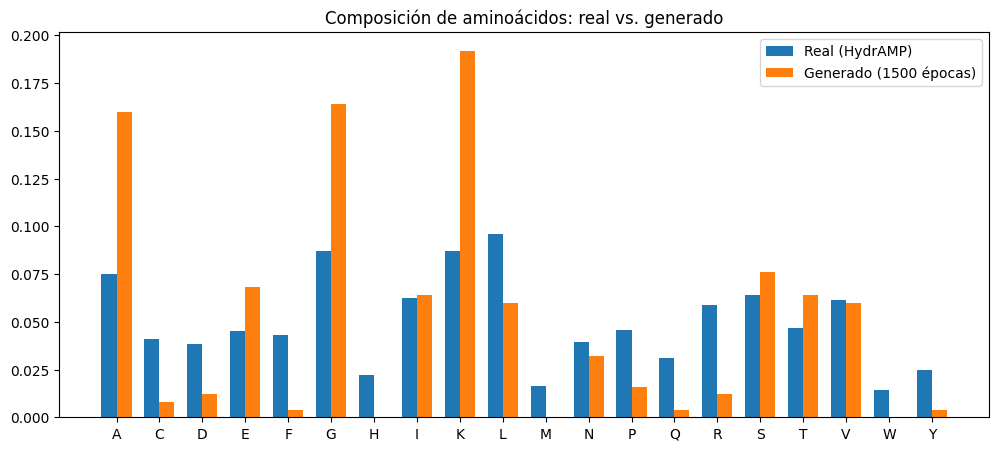

In [15]:
from collections import Counter

def composicion(secuencias):
    contador = Counter("".join(secuencias))
    total = sum(contador.values())
    return {aa: contador.get(aa, 0) / total for aa in AMINOACIDOS}

comp_real = composicion(df_final["sequence"].tolist())
comp_generado = composicion(secuencias_generadas)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(AMINOACIDOS))
width = 0.35
ax.bar(x - width/2, [comp_real[aa] for aa in AMINOACIDOS], width, label="Real (HydrAMP)")
ax.bar(x + width/2, [comp_generado[aa] for aa in AMINOACIDOS], width, label="Generado (1500 épocas)")
ax.set_xticks(x)
ax.set_xticklabels(list(AMINOACIDOS))
ax.legend()
ax.set_title("Composición de aminoácidos: real vs. generado")
plt.savefig(f"{PROC_DIR}/composicion_fase3.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
df_logs = pd.read_csv(LOG_PATH)
df_logs.columns = ["epoch", "loss_total", "loss_noise", "loss_round"]

# Filter for epochs 1 to 300 (inclusive)
df_loss_sin_lamba_round = df_logs[(df_logs['epoch'] >= 1) & (df_logs['epoch'] <= 300)].copy()

# Filter for epochs 301 onwards (inclusive)
df_loss_con_lamba_round = df_logs[df_logs['epoch'] >= 301].copy()

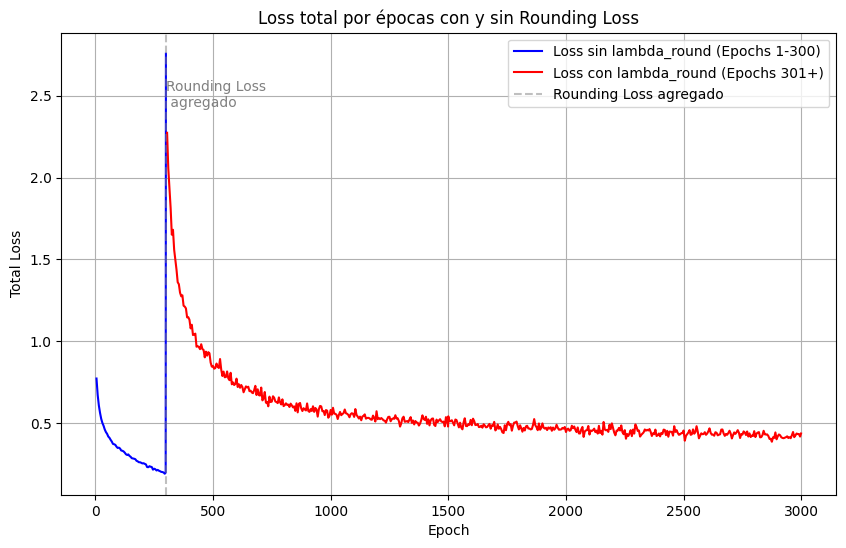

In [17]:
plt.figure(figsize=(10, 6))

# Plot df_loss_sin_lamba_round
plt.plot(df_loss_sin_lamba_round['epoch'], df_loss_sin_lamba_round['loss_total'], label='Loss sin lambda_round (Epochs 1-300)', color='blue')

# Plot df_loss_con_lamba_round
plt.plot(df_loss_con_lamba_round['epoch'], df_loss_con_lamba_round['loss_total'], label='Loss con lambda_round (Epochs 301+)', color='red')

# Add vertical dotted line
plt.axvline(x=300, color='gray', linestyle='--', label='Rounding Loss agregado', alpha=0.5)
plt.text(300, plt.ylim()[1]*0.9, 'Rounding Loss \n agregado', verticalalignment='top', color='gray')

plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Loss total por épocas con y sin Rounding Loss')
plt.legend()
plt.grid(True)
plt.savefig(f"{PROC_DIR}/loss_por_epoca.png", dpi=500, bbox_inches="tight")
plt.show()

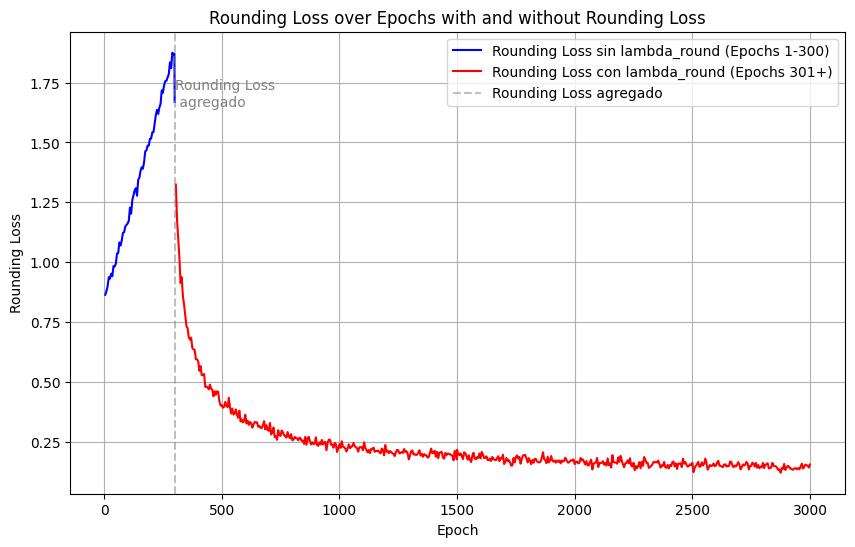

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot df_loss_sin_lamba_round
plt.plot(df_loss_sin_lamba_round['epoch'], df_loss_sin_lamba_round['loss_round'], label='Rounding Loss sin lambda_round (Epochs 1-300)', color='blue')

# Plot df_loss_con_lamba_round
plt.plot(df_loss_con_lamba_round['epoch'], df_loss_con_lamba_round['loss_round'], label='Rounding Loss con lambda_round (Epochs 301+)', color='red')

# Add vertical dotted line
plt.axvline(x=300, color='gray', linestyle='--', label='Rounding Loss agregado', alpha=0.5)
plt.text(300, plt.ylim()[1]*0.9, 'Rounding Loss \n agregado', verticalalignment='top', color='gray')

plt.xlabel('Epoch')
plt.ylabel('Rounding Loss')
plt.title('Rounding Loss over Epochs with and without Rounding Loss')
plt.legend()
plt.grid(True)
plt.savefig(f"{PROC_DIR}/rounding_loss_por_epoca.png", dpi=500, bbox_inches="tight")
plt.show()

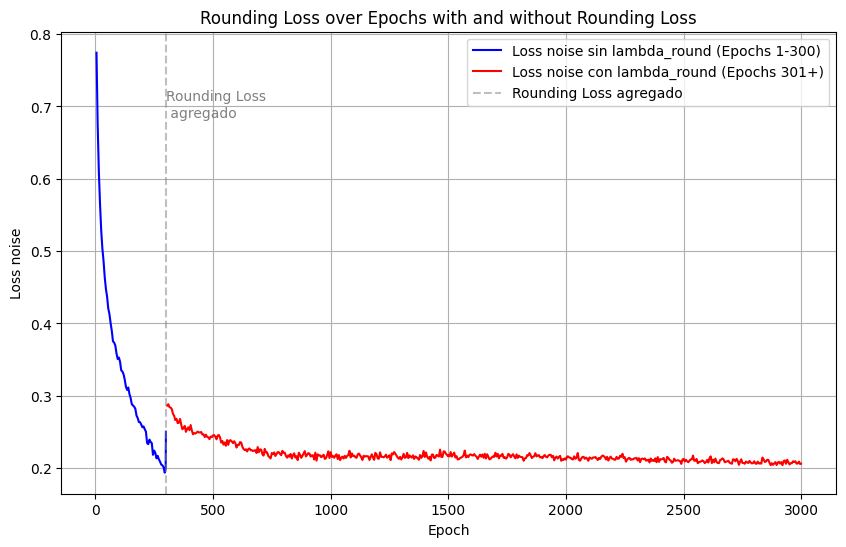

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot df_loss_sin_lamba_round
plt.plot(df_loss_sin_lamba_round['epoch'], df_loss_sin_lamba_round['loss_noise'], label='Loss noise sin lambda_round (Epochs 1-300)', color='blue')

# Plot df_loss_con_lamba_round
plt.plot(df_loss_con_lamba_round['epoch'], df_loss_con_lamba_round['loss_noise'], label='Loss noise con lambda_round (Epochs 301+)', color='red')

# Add vertical dotted line
plt.axvline(x=300, color='gray', linestyle='--', label='Rounding Loss agregado', alpha=0.5)
plt.text(300, plt.ylim()[1]*0.9, 'Rounding Loss \n agregado', verticalalignment='top', color='gray')

plt.xlabel('Epoch')
plt.ylabel('Loss noise')
plt.title('Rounding Loss over Epochs with and without Rounding Loss')
plt.legend()
plt.grid(True)
plt.savefig(f"{PROC_DIR}/loss_noise_por_epoca.png", dpi=500, bbox_inches="tight")
plt.show()

## Generación (muestreo) y decodificación

### Comprobamos el sesgo del modelo

In [20]:
from collections import Counter

@torch.no_grad()
def generar(n_muestras=5, max_len=MAX_LEN):
    x = torch.randn(n_muestras, max_len, EMBED_DIM, device=device)
    mask = torch.ones(n_muestras, max_len, device=device)

    for t_step in reversed(range(T)):
        t = torch.full((n_muestras,), t_step, device=device, dtype=torch.long)
        pred_noise = denoise_net(x, t, mask)

        alpha_t = alphas[t_step]
        alpha_cum_t = alphas_cumprod[t_step]
        beta_t = betas[t_step]

        noise = torch.randn_like(x) if t_step > 0 else torch.zeros_like(x)
        x = (1 / alpha_t.sqrt()) * (x - (beta_t / (1 - alpha_cum_t).sqrt()) * pred_noise) + beta_t.sqrt() * noise

    return x

@torch.no_grad()
def decodificar_embeddings(x_generado):
    """Decodificación por vecino más cercano (argmin) — la versión original.
    Se deja disponible por referencia, pero usar la de softmax de aquí en adelante."""
    tabla = embedding_layer.embed.weight.data
    secuencias = []
    for muestra in x_generado:
        ids = []
        for pos in range(muestra.size(0)):
            dists = torch.cdist(muestra[pos].unsqueeze(0), tabla)
            ids.append(dists.argmin().item())
        secuencias.append(decodificar(ids))
    return secuencias

@torch.no_grad()
def decodificar_embeddings_softmax(x_generado, temperatura=1.0):
    """Decodificación por muestreo (softmax + temperatura) — la que resolvió
    el problema de colapso hacia unos pocos aminoácidos."""
    tabla = embedding_layer.embed.weight.data
    secuencias = []
    for muestra in x_generado:
        ids = []
        for pos in range(muestra.size(0)):
            dists = torch.cdist(muestra[pos].unsqueeze(0), tabla).squeeze(0)
            logits = -dists / temperatura
            probs = torch.softmax(logits, dim=0)
            token_id = torch.multinomial(probs, num_samples=1).item()
            ids.append(token_id)
        secuencias.append(decodificar(ids))
    return secuencias

def composicion(secuencias):
    """Frecuencia relativa de cada aminoácido en una lista de secuencias."""
    contador = Counter("".join(secuencias))
    total = sum(contador.values())
    return {aa: contador.get(aa, 0) / total for aa in AMINOACIDOS}

# Composición real, para comparar (recalculada por si también se perdió)
comp_real = composicion(df_final["sequence"].tolist())

In [21]:
for temp in [0.5, 1.0, 1.5, 2.0]:
    muestras = generar(n_muestras=30)
    secs = decodificar_embeddings_softmax(muestras, temperatura=temp)
    comp = composicion(secs)
    tvd = sum(abs(comp[aa] - comp_real[aa]) for aa in AMINOACIDOS) / 2
    print(f"temp={temp}: TVD respecto a composición real = {tvd:.4f}")

temp=0.5: TVD respecto a composición real = 0.1673
temp=1.0: TVD respecto a composición real = 0.0830
temp=1.5: TVD respecto a composición real = 0.0998
temp=2.0: TVD respecto a composición real = 0.1252


In [22]:
# Verificación: TVD contra una distribución uniforme (baseline "sin aprendizaje")
comp_uniforme = {aa: 1/len(AMINOACIDOS) for aa in AMINOACIDOS}
tvd_uniforme = sum(abs(comp_real[aa] - comp_uniforme[aa]) for aa in AMINOACIDOS) / 2
print(f"TVD real vs. uniforme (baseline): {tvd_uniforme:.4f}")

TVD real vs. uniforme (baseline): 0.1918


In [23]:
muestras = generar(n_muestras=10)
secs_temp2 = decodificar_embeddings_softmax(muestras, temperatura=2.0)
for s in secs_temp2:
    print(s)

LEATLKYTINALWVEYWSMDTVVKAGIRIVTLIADQMCLLGFPCNQAPKE
AVMALSYCSTVNSHNIDKRQTLAKHIVKETKKMWVKFFGPNSLLTFEQEK
IKQQFRFTIACDSGARAFQGANVIDCAAGWKSATASKEDARCTTTESVCN
QPYSERIWTFCLKVESMFNKTLGWRRCRRFMGKAVLGACIKVLNKECLGQ
SPFMLHHMCFGRKASVDRAFLGNPGKEVNMALSTKHVKSRSSYLNDILRN
IEYMWDEKNCTCCIEDDDETKPILKCKAVHTEVEMVWRLTVKFMVTVNKK
MKCQSNYTEPHEGLFNSSPNGDLALMTHRFKQQISANQTTVRKEQDEVKN
DFVPQAFDLAVAKCAANYFLECDENNYAKECHFCAFKVDTCYASAPRKCT
RDKIRVLFQCHYALVVVNCKRWEPAMHYWITAKISIAADKCLNGPGYAVK
KDVMTRAKWTAYSGQLSGRADILEWEHAEADSKLEEYAHYWLCDQKQPWQ


Composición con muestreo (temp=2.0): {'A': 0.06733333333333333, 'C': 0.04133333333333333, 'D': 0.048666666666666664, 'E': 0.068, 'F': 0.03866666666666667, 'G': 0.05733333333333333, 'H': 0.034666666666666665, 'I': 0.059333333333333335, 'K': 0.07733333333333334, 'L': 0.05733333333333333, 'M': 0.034, 'N': 0.051333333333333335, 'P': 0.04, 'Q': 0.042, 'R': 0.04533333333333334, 'S': 0.06066666666666667, 'T': 0.05466666666666667, 'V': 0.052, 'W': 0.032, 'Y': 0.038}


NameError: name 'comp_argmin_actual' is not defined

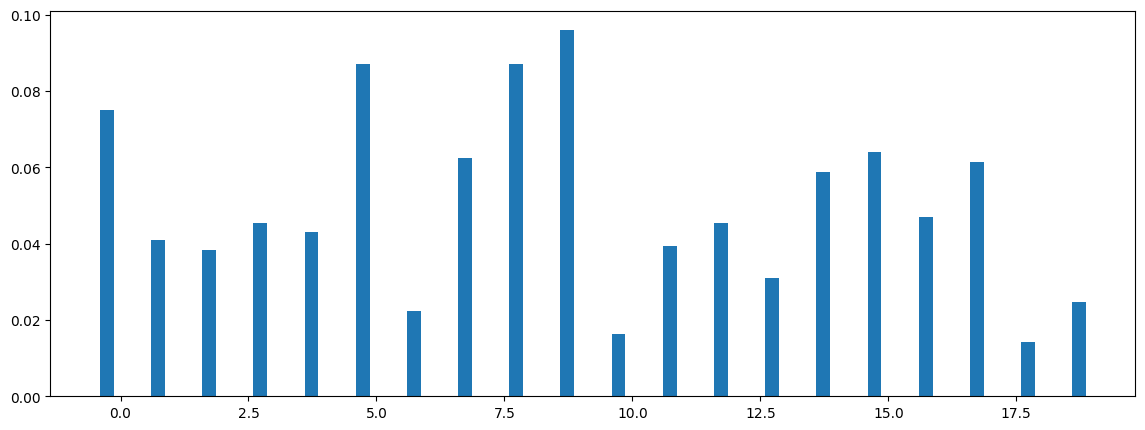

In [25]:
muestras = generar(n_muestras=30)  # o generar_condicionado si ya estás en Fase 3
secs_temp = decodificar_embeddings_softmax(muestras, temperatura=2.0)
comp_temp = composicion(secs_temp)

print("Composición con muestreo (temp=2.0):", comp_temp)

# Gráfico comparando real vs. argmin vs. muestreo, para que quede clarísimo en la diapositiva
fig, ax = plt.subplots(figsize=(14,5))
x = np.arange(len(AMINOACIDOS)); width = 0.27
ax.bar(x - width, [comp_real[aa] for aa in AMINOACIDOS], width, label="Real")
ax.bar(x, [comp_argmin_actual[aa] for aa in AMINOACIDOS], width, label="Generado (argmin)", color="firebrick")
ax.bar(x + width, [comp_temp[aa] for aa in AMINOACIDOS], width, label="Generado (muestreo T=2.0)", color="mediumseagreen")
ax.set_xticks(x); ax.set_xticklabels(list(AMINOACIDOS))
ax.legend()
ax.set_title("Argmin vs. muestreo: el decode importa más que el entrenamiento")
plt.tight_layout()
plt.savefig(f"{PROC_DIR}/slide_argmin_vs_muestreo.png", dpi=200, bbox_inches="tight")
plt.show()

# Fase 3

In [ ]:
# Normalización de las condiciones continuas (solo con los valores válidos)
MIC_MEAN = df_final.loc[df_final["mic_available"]==1, "cMIC"].mean()
MIC_STD  = df_final.loc[df_final["mic_available"]==1, "cMIC"].std()

# cHC50 lo pasamos a log10 antes de normalizar (es una concentración, igual que MIC)
df_final["cHC50_log"] = np.log10(df_final["cHC50"])
HC50_MEAN = df_final.loc[df_final["hc50_valido"]==1, "cHC50_log"].mean()
HC50_STD  = df_final.loc[df_final["hc50_valido"]==1, "cHC50_log"].std()

print(f"MIC: mean={MIC_MEAN:.3f}, std={MIC_STD:.3f}")
print(f"HC50(log10): mean={HC50_MEAN:.3f}, std={HC50_STD:.3f}")

class PeptidosDatasetCondicionado(torch.utils.data.Dataset):
    def __init__(self, df, col_seq, max_len=MAX_LEN):
        self.seqs = df[col_seq].tolist()
        self.cAMP = df["cAMP"].values.astype(np.float32)

        self.mic_avail = df["mic_available"].values.astype(np.float32)
        mic_norm = (df["cMIC"].values - MIC_MEAN) / MIC_STD
        self.cMIC = np.nan_to_num(mic_norm, nan=0.0).astype(np.float32)

        self.hc50_valid = df["hc50_valido"].values.astype(np.float32)
        hc50_norm = (df["cHC50_log"].values - HC50_MEAN) / HC50_STD
        self.cHC50 = hc50_norm.astype(np.float32)

        self.max_len = max_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        ids = torch.tensor(codificar(self.seqs[idx], self.max_len), dtype=torch.long)
        mask = (ids != VOCAB["<PAD>"]).float()
        cond = torch.tensor([
            self.cAMP[idx],
            self.cMIC[idx], self.mic_avail[idx],
            self.cHC50[idx], self.hc50_valid[idx],
        ], dtype=torch.float32)
        return ids, mask, cond

dataset_cond = PeptidosDatasetCondicionado(df_final, "sequence")
ids_ej, mask_ej, cond_ej = dataset_cond[0]
print(f"Dataset condicionado: {len(dataset_cond)} secuencias")
print("Ejemplo de condición [cAMP, cMIC_norm, mic_avail, cHC50_norm, hc50_valid]:", cond_ej)

Arquitectura condicionada


In [ ]:
COND_DIM = 5  # [cAMP, cMIC_norm, mic_avail, cHC50_norm, hc50_valid]

class DenoisingNetCond(nn.Module):
    def __init__(self, embed_dim, n_layers, n_heads, max_len, cond_dim=COND_DIM):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.SiLU(), nn.Linear(embed_dim, embed_dim)
        )
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, embed_dim), nn.SiLU(), nn.Linear(embed_dim, embed_dim)
        )
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
            batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x_noisy, t, mask, cond):
        t_emb = self.time_mlp(timestep_embedding(t, x_noisy.size(-1)))
        c_emb = self.cond_mlp(cond)
        x = x_noisy + t_emb.unsqueeze(1) + c_emb.unsqueeze(1)
        pad_mask = (mask == 0)
        h = self.transformer(x, src_key_padding_mask=pad_mask)
        return self.out_proj(h)

denoise_net_cond = DenoisingNetCond(EMBED_DIM, N_LAYERS, N_HEADS, MAX_LEN).to(device)
n_params = sum(p.numel() for p in list(embedding_layer.parameters()) + list(denoise_net_cond.parameters()))
print(f"Parámetros totales (condicionado): {n_params:,}")

## Entrenamiento con warm start desde el baseline

In [ ]:
CHECKPOINT_PATH_COND = f"{PROC_DIR}/checkpoint_condicionado.pt"  # ruta NUEVA, distinta a la del baseline

BATCH_SIZE = 64
EPOCHS_COND = 1000
LR = 1e-4
LAMBDA_ROUND = 1.0

loader_cond = DataLoader(dataset_cond, batch_size=BATCH_SIZE, shuffle=True)
optimizer_cond = torch.optim.Adam(
    list(embedding_layer.parameters()) + list(denoise_net_cond.parameters()), lr=LR
)

epoch_inicial = 0
if os.path.exists(CHECKPOINT_PATH_COND):
    ckpt = torch.load(CHECKPOINT_PATH_COND, map_location=device)
    embedding_layer.load_state_dict(ckpt["embedding"])
    denoise_net_cond.load_state_dict(ckpt["denoise_net"])
    optimizer_cond.load_state_dict(ckpt["optimizer"])
    epoch_inicial = ckpt["epoch"] + 1
    print(f"Checkpoint condicionado encontrado, retomando desde epoch {epoch_inicial}")
else:
    ckpt_base = f"{PROC_DIR}/checkpoint_baseline.pt"
    if os.path.exists(ckpt_base):
        ckpt = torch.load(ckpt_base, map_location=device)
        embedding_layer.load_state_dict(ckpt["embedding"])
        denoise_net_cond.load_state_dict(ckpt["denoise_net"], strict=False)  # cond_mlp queda sin cargar (es nuevo)
        print("Warm start: pesos del baseline reutilizados (embedding + transformer)")
    else:
        print("Sin checkpoint previo, entrenando desde cero")

for epoch in range(epoch_inicial, EPOCHS_COND):
    total_loss, total_noise, total_round = 0.0, 0.0, 0.0
    for ids, mask, cond in loader_cond:
        ids, mask, cond = ids.to(device), mask.to(device), cond.to(device)
        x0 = embedding_layer(ids)

        t = torch.randint(0, T, (ids.size(0),), device=device)
        x_t, noise = forward_diffusion(x0, t)

        pred_noise = denoise_net_cond(x_t, t, mask, cond)

        loss_noise = ((pred_noise - noise) ** 2) * mask.unsqueeze(-1)
        loss_noise = loss_noise.sum() / mask.sum() / EMBED_DIM
        loss_round = rounding_loss(x_t, t, pred_noise, ids, mask)
        loss = loss_noise + LAMBDA_ROUND * loss_round

        optimizer_cond.zero_grad()
        loss.backward()
        optimizer_cond.step()

        total_loss += loss.item(); total_noise += loss_noise.item(); total_round += loss_round.item()

    if epoch % 5 == 0 or epoch == EPOCHS_COND - 1:
        n = len(loader_cond)
        print(f"Epoch {epoch}: loss = {total_loss/n:.4f} (noise={total_noise/n:.4f}, round={total_round/n:.4f})")
        torch.save({
            "embedding": embedding_layer.state_dict(),
            "denoise_net": denoise_net_cond.state_dict(),
            "optimizer": optimizer_cond.state_dict(),
            "epoch": epoch,
        }, CHECKPOINT_PATH_COND)

## Generación condicionada

In [ ]:
@torch.no_grad()
def generar_condicionado(cond_target, n_muestras=5, max_len=MAX_LEN):
    x = torch.randn(n_muestras, max_len, EMBED_DIM, device=device)
    mask = torch.ones(n_muestras, max_len, device=device)
    cond = cond_target.unsqueeze(0).repeat(n_muestras, 1).to(device)

    for t_step in reversed(range(T)):
        t = torch.full((n_muestras,), t_step, device=device, dtype=torch.long)
        pred_noise = denoise_net_cond(x, t, mask, cond)
        alpha_t, alpha_cum_t, beta_t = alphas[t_step], alphas_cumprod[t_step], betas[t_step]
        noise = torch.randn_like(x) if t_step > 0 else torch.zeros_like(x)
        x = (1/alpha_t.sqrt()) * (x - (beta_t/(1-alpha_cum_t).sqrt())*pred_noise) + beta_t.sqrt()*noise
    return x

# Ejemplo: cAMP=1 (antimicrobiano), MIC bajo (potente), HC50 alto (seguro)
mic_target_norm = (0.5 - MIC_MEAN) / MIC_STD
hc50_target_norm = (np.log10(150) - HC50_MEAN) / HC50_STD
cond_target = torch.tensor([1.0, mic_target_norm, 1.0, hc50_target_norm, 1.0], dtype=torch.float32)

muestras = generar_condicionado(cond_target, n_muestras=10)
secs = decodificar_embeddings_softmax(muestras, temperatura=2.0)
for s in secs:
    print(s)